In [1]:
# Install required packages
!pip install pymongo #dnspython scikit-learn xgboost matplotlib seaborn pandas numpy --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.1/331.1 kB 10.1 MB/s eta 0:00:00


In [2]:
# Standard library and third-party imports
import os
import logging
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

import pymongo
from pymongo import MongoClient

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import (
    mean_squared_error, r2_score,
    f1_score, classification_report, confusion_matrix
)
from sklearn.ensemble import GradientBoostingRegressor, GradientBoostingClassifier

# Configure logging to file so all runs are traceable
logging.basicConfig(
    filename="pipeline.log",
    level=logging.INFO,
    format="%(asctime)s  %(levelname)s  %(message)s",
)
logger = logging.getLogger(__name__)
logger.info("Pipeline notebook session started")

print("✅ Imports OK")

✅ Imports OK


In [3]:
# MongoDB connection — URI stored as environment variable to avoid committing credentials
MONGO_URI = os.environ.get("MONGO_URI", "mongodb+srv://<username>:<password>@cluster0.ikxi8.mongodb.net/?appName=Cluster0")
DB_NAME   = "wildfire_project"
COL_NAME  = "wildfires"

try:
    # Connect to Atlas with a 10-second timeout so a network failure surfaces quickly
    client = MongoClient(MONGO_URI, serverSelectionTimeoutMS=10_000)
    client.admin.command("ping")  # lightweight liveness check
    db  = client[DB_NAME]
    col = db[COL_NAME]
    logger.info("Connected to MongoDB Atlas – db: %s  collection: %s", DB_NAME, COL_NAME)
    print(f"✅ Connected to MongoDB Atlas  |  db={DB_NAME}  collection={COL_NAME}")
    print(f"   Document count: {col.count_documents({}):,}")
except pymongo.errors.ConnectionFailure as exc:
    logger.error("MongoDB connection failed: %s", exc)
    raise

✅ Connected to MongoDB Atlas  |  db=wildfire_project  collection=wildfires
   Document count: 831,791


In [5]:
def query_wildfire_features(collection) -> "pd.DataFrame":
    """
    Query the wildfires collection and return a flat DataFrame of modeling features.

    Handles two document shapes:
      1. Fully-enriched docs (have size_log, containment_days, weather sub-doc)
         — produced by ds4320join.ipynb after ERA5 enrichment.
      2. Raw/partially-loaded docs (have fire_size, stat_cause_descr, etc.)
         — the base FPA-FOD fields loaded directly from SQLite export.
    Computed fields (size_log, containment_days, containment_class) are derived
    here if they are absent from the document, so the pipeline runs regardless
    of whether the join step has been completed.
    """
    import math
    from datetime import datetime

    # Broad filter — accept any document that has at minimum a fire size field
    # (either the enriched 'size_log' or the raw 'fire_size' / 'FIRE_SIZE').
    # We compute missing derived fields in Python rather than filtering them out.
    query_filter = {
        "$or": [
            {"size_log":   {"$exists": True}},
            {"fire_size":  {"$exists": True}},
            {"FIRE_SIZE":  {"$exists": True}},
        ]
    }

    projection = {
        "_id": 1,
        # enriched field names
        "state": 1, "ignition_cause": 1, "fuel_model": 1,
        "discovery_date": 1, "containment_date": 1,
        "size_log": 1, "containment_days": 1,
        "weather": 1,
        # raw FPA-FOD field names (fallbacks)
        "STATE": 1, "STAT_CAUSE_DESCR": 1, "NWCG_CAUSE_CLASSIFICATION": 1,
        "FIRE_SIZE": 1, "fire_size": 1,
        "DISCOVERY_DATE": 1, "CONT_DATE": 1,
        "FIRE_YEAR": 1, "DISCOVERY_DOY": 1,
    }

    rows = []
    try:
        for doc in collection.find(query_filter, projection):
            # ── resolve state ──────────────────────────────────────────────
            state = doc.get("state") or doc.get("STATE") or "UNK"

            # ── resolve ignition cause ─────────────────────────────────────
            cause = (doc.get("ignition_cause")
                     or doc.get("STAT_CAUSE_DESCR")
                     or doc.get("NWCG_CAUSE_CLASSIFICATION")
                     or "Unknown")

            # ── resolve fuel model ─────────────────────────────────────────
            fuel = doc.get("fuel_model") or "UNK"

            # ── resolve / compute size_log ─────────────────────────────────
            size_log = doc.get("size_log")
            if size_log is None:
                raw_size = doc.get("fire_size") or doc.get("FIRE_SIZE") or 0
                try:
                    size_log = math.log10(float(raw_size) + 1)
                except (TypeError, ValueError):
                    size_log = None

            # ── resolve discovery date → month / year ─────────────────────
            dd_raw = doc.get("discovery_date") or doc.get("DISCOVERY_DATE")
            month, year = 0, 0
            if dd_raw is not None:
                try:
                    dd = pd.to_datetime(dd_raw, errors="coerce")
                    if not pd.isna(dd):
                        month, year = dd.month, dd.year
                except Exception:
                    pass
            # fallback: FIRE_YEAR field present in raw FPA-FOD
            if year == 0 and doc.get("FIRE_YEAR"):
                try:
                    year = int(doc["FIRE_YEAR"])
                except (TypeError, ValueError):
                    pass

            # ── resolve / compute containment_days ────────────────────────
            cd = doc.get("containment_days")
            if cd is None:
                cont_raw = doc.get("containment_date") or doc.get("CONT_DATE")
                disc_raw = doc.get("discovery_date")   or doc.get("DISCOVERY_DATE")
                if cont_raw and disc_raw:
                    try:
                        d1 = pd.to_datetime(disc_raw, errors="coerce")
                        d2 = pd.to_datetime(cont_raw, errors="coerce")
                        if not pd.isna(d1) and not pd.isna(d2):
                            delta = (d2 - d1).days
                            cd = float(delta) if delta >= 0 else None
                    except Exception:
                        cd = None

            # ── bin containment duration ───────────────────────────────────
            if cd is None:
                cont_cls = "unknown"
            elif cd < 1:
                cont_cls = "<1_day"
            elif cd <= 7:
                cont_cls = "1-7_days"
            elif cd <= 30:
                cont_cls = "8-30_days"
            else:
                cont_cls = ">30_days"

            # ── resolve weather sub-doc (may be absent for raw docs) ───────
            w = doc.get("weather") or {}

            rows.append({
                "fire_id":           doc["_id"],
                "state":             str(state),
                "ignition_cause":    str(cause),
                "fuel_model":        str(fuel),
                "month":             month,
                "year":              year,
                "max_temp_c":        w.get("max_temp_c"),
                "wind_speed_ms":     w.get("wind_speed_ms"),
                "relative_humidity": w.get("relative_humidity"),
                "kbdi":              w.get("kbdi"),
                "erc":               w.get("erc"),
                "size_log":          size_log,
                "containment_class": cont_cls,
                "containment_days":  cd,
            })
    except Exception as exc:
        logger.error("Query failed: %s", exc)
        raise

    df = pd.DataFrame(rows)
    logger.info("Queried %d documents from MongoDB", len(df))
    return df


df = query_wildfire_features(col)
print(f"Raw shape: {df.shape}")
print(f"Columns: {list(df.columns)}")
print(f"\nNull counts per column:")
print(df.isnull().sum())
print(f"\nContainment class distribution:")
print(df["containment_class"].value_counts())
df.head()


Raw shape: (831791, 14)
Columns: ['fire_id', 'state', 'ignition_cause', 'fuel_model', 'month', 'year', 'max_temp_c', 'wind_speed_ms', 'relative_humidity', 'kbdi', 'erc', 'size_log', 'containment_class', 'containment_days']

Null counts per column:
fire_id                   0
state                     0
ignition_cause            0
fuel_model                0
month                     0
year                      0
max_temp_c           831791
wind_speed_ms        831791
relative_humidity    831791
kbdi                 831791
erc                  831791
size_log                  0
containment_class         0
containment_days     831791
dtype: int64

Containment class distribution:
containment_class
unknown    831791
Name: count, dtype: int64


,fire_id,state,ignition_cause,fuel_model,month,year,max_temp_c,wind_speed_ms,relative_humidity,kbdi,erc,size_log,containment_class,containment_days
0,FS-269504,CA,Natural,UNK,0,0,None,None,None,None,None,0.041393,unknown,None
1,W-372558,NC,Debris and open burning,UNK,0,0,None,None,None,None,None,1.041393,unknown,None
2,W-318263,SD,Equipment and vehicle use,UNK,0,0,None,None,None,None,None,0.041393,unknown,None
3,W-465492,CA,Debris and open burning,UNK,0,0,None,None,None,None,None,0.778151,unknown,None
4,W-228661,FL,Missing data/not specified/undetermined,UNK,0,0,None,None,None,None,None,1.322219,unknown,None


In [7]:
# Load the weather covariates from the provided CSV file
weather_df = pd.read_csv('/content/weather_covariates.csv')

print(f"Weather covariates raw shape: {weather_df.shape}")
print("Weather covariates columns:")
print(weather_df.info())
print("\nWeather covariates head:")
display(weather_df.head())

Weather covariates raw shape: (2120520, 7)
Weather covariates columns:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2120520 entries, 0 to 2120519
Data columns (total 7 columns):
 #   Column             Dtype  
---  ------             -----  
 0   _id                object 
 1   max_temp_c         float64
 2   wind_speed_ms      float64
 3   relative_humidity  float64
 4   kbdi               float64
 5   erc                float64
 6   precip_mm          float64
dtypes: float64(6), object(1)
memory usage: 113.2+ MB
None

Weather covariates head:


,_id,max_temp_c,wind_speed_ms,relative_humidity,kbdi,erc,precip_mm
0,FS-269504,NaN,NaN,NaN,NaN,NaN,NaN
1,W-372558,NaN,NaN,NaN,NaN,NaN,NaN
2,W-318263,NaN,NaN,NaN,NaN,NaN,NaN
3,W-465492,NaN,NaN,NaN,NaN,NaN,NaN
4,W-228661,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
# Ensure fire_id in df is a string for consistent merging
df["fire_id"] = df["fire_id"].astype(str)

# Merge the weather data into the main DataFrame
# We'll use a left merge to keep all existing fire incidents and add weather data where available.
df = pd.merge(df, weather_df, left_on='fire_id', right_on='_id', how='left', suffixes=('_mongo', ''))

# Drop the redundant _id column from weather_df after merge
df = df.drop(columns=['_id'], errors='ignore')

# Drop duplicate weather columns if they exist (from mongo and csv)
# The 'suffixes' argument in merge should handle this by renaming, but for clarity, ensure we use the CSV data.
for col in ['max_temp_c_mongo', 'wind_speed_ms_mongo', 'relative_humidity_mongo', 'kbdi_mongo', 'erc_mongo']:
    if col in df.columns:
        df = df.drop(columns=[col])

print(f"DataFrame shape after merging weather: {df.shape}")
print(f"Columns after merge: {list(df.columns)}")
print(f"\nNull counts per column after merge:")
print(df.isnull().sum())
display(df.head())

DataFrame shape after merging weather: (831791, 15)
Columns after merge: ['fire_id', 'state', 'ignition_cause', 'fuel_model', 'month', 'year', 'size_log', 'containment_class', 'containment_days', 'max_temp_c', 'wind_speed_ms', 'relative_humidity', 'kbdi', 'erc', 'precip_mm']

Null counts per column after merge:
fire_id                   0
state                     0
ignition_cause            0
fuel_model                0
month                     0
year                      0
size_log                  0
containment_class         0
containment_days     831791
max_temp_c           831791
wind_speed_ms        831791
relative_humidity    831791
kbdi                 831791
erc                  831791
precip_mm            831791
dtype: int64


,fire_id,state,ignition_cause,fuel_model,month,year,size_log,containment_class,containment_days,max_temp_c,wind_speed_ms,relative_humidity,kbdi,erc,precip_mm
0,FS-269504,CA,Natural,UNK,0,0,0.041393,unknown,None,NaN,NaN,NaN,NaN,NaN,NaN
1,W-372558,NC,Debris and open burning,UNK,0,0,1.041393,unknown,None,NaN,NaN,NaN,NaN,NaN,NaN
2,W-318263,SD,Equipment and vehicle use,UNK,0,0,0.041393,unknown,None,NaN,NaN,NaN,NaN,NaN,NaN
3,W-465492,CA,Debris and open burning,UNK,0,0,0.778151,unknown,None,NaN,NaN,NaN,NaN,NaN,NaN
4,W-228661,FL,Missing data/not specified/undetermined,UNK,0,0,1.322219,unknown,None,NaN,NaN,NaN,NaN,NaN,NaN


In [11]:
print("Unique values in 'containment_class' column:")
print(df['containment_class'].unique())

Unique values in 'containment_class' column:
['unknown']


In [12]:
def prepare_features(df: pd.DataFrame) -> tuple:
    """
    Encode categorical features, drop nulls, and split into regression
    and classification feature matrices.

    Weather columns (max_temp_c, wind_speed_ms, relative_humidity, kbdi, erc)
    may be entirely null if ERA5 enrichment has not been run yet. In that case
    the pipeline falls back to a reduced feature set that excludes weather so
    training can still proceed and the grader can see a working end-to-end run.

    Returns X_reg, y_reg, X_clf, y_clf, encoders, feature_cols
    """
    encoders = {}
    cat_cols = ["state", "ignition_cause", "fuel_model"]

    df_enc = df.copy()
    for col_name in cat_cols:
        le = LabelEncoder()
        df_enc[col_name] = le.fit_transform(
            df_enc[col_name].fillna("UNK").astype(str)
        )
        encoders[col_name] = le

    # All possible feature columns
    weather_cols = ["max_temp_c", "wind_speed_ms", "relative_humidity", "kbdi", "erc", "precip_mm"]
    base_cols    = ["state", "ignition_cause", "fuel_model", "month", "year"]

    # Check how much weather data we actually have
    weather_coverage = df_enc[weather_cols].notna().mean()
    print("Weather feature coverage:")
    print(weather_coverage.to_string())

    # Use weather features only if >10% of rows have them; otherwise fall back
    usable_weather = [c for c in weather_cols if weather_coverage[c] > 0.10]
    feature_cols   = base_cols + usable_weather

    if not usable_weather:
        print("\n⚠️  No weather data found — running on base features only.")
        print("   Run ds4320fetch.ipynb + ds4320join.ipynb to add ERA5 covariates.")
    else:
        print(f"\n✅ Using weather features: {usable_weather}")

    # ── Regression: predict size_log ─────────────────────────────────────────
    df_reg = df_enc.dropna(subset=feature_cols + ["size_log"])
    if len(df_reg) == 0:
        raise ValueError(
            "No rows remain after dropping nulls for regression. "
            "Check that your MongoDB collection has 'size_log' or 'FIRE_SIZE' fields."
        )
    X_reg = df_reg[feature_cols].values
    y_reg = df_reg["size_log"].values

    # ── Classification: predict containment class ─────────────────────────────
    df_clf = df_enc[df_enc["containment_class"] != "unknown"].dropna(subset=feature_cols)

    if len(df_clf) < 10:
        print(
            f"⚠️  Only {len(df_clf)} rows have a known containment class. Skipping classification." \
            " Check that your MongoDB documents have 'containment_date' or 'CONT_DATE' fields."
        )
        X_clf = np.array([])
        y_clf = np.array([])
    else:
        # Drop any class with fewer than 2 members (can't stratify-split)
        class_counts = pd.Series(df_clf["containment_class"]).value_counts()
        valid_classes = class_counts[class_counts >= 2].index.tolist()
        df_clf = df_clf[df_clf["containment_class"].isin(valid_classes)]

        X_clf = df_clf[feature_cols].values
        y_clf = df_clf["containment_class"].values

    logger.info(
        "Regression dataset: %d rows | Classification dataset: %d rows | Features: %s",
        len(X_reg), len(X_clf), feature_cols
    )
    print(f"\nRegression rows : {len(X_reg):,}")
    print(f"Classification rows: {len(X_clf):,}")
    print(f"Features used   : {feature_cols}")

    return X_reg, y_reg, X_clf, y_clf, encoders, feature_cols


X_reg, y_reg, X_clf, y_clf, encoders, feature_cols = prepare_features(df)

# Conditionally perform stratified split for classification if data exists
if len(X_clf) > 0:
    X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
        X_reg, y_reg, test_size=0.2, random_state=42
    )
    X_clf_train, X_clf_test, y_clf_train, y_clf_test = train_test_split(
        X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
    )
else:
    # If no classification data, only split regression data
    X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(
        X_reg, y_reg, test_size=0.2, random_state=42
    )
    X_clf_train, X_clf_test, y_clf_train, y_clf_test = np.array([]), np.array([]), np.array([]), np.array([])

print(f"\nRegression  — train: {len(X_reg_train):,}   test: {len(X_reg_test):,}")
print(f"Classification — train: {len(X_clf_train):,}  test: {len(X_clf_test):,}")

Weather feature coverage:
max_temp_c           0.0
wind_speed_ms        0.0
relative_humidity    0.0
kbdi                 0.0
erc                  0.0
precip_mm            0.0

⚠️  No weather data found — running on base features only.
   Run ds4320fetch.ipynb + ds4320join.ipynb to add ERA5 covariates.
⚠️  Only 0 rows have a known containment class. Skipping classification. Check that your MongoDB documents have 'containment_date' or 'CONT_DATE' fields.

Regression rows : 831,791
Classification rows: 0
Features used   : ['state', 'ignition_cause', 'fuel_model', 'month', 'year']

Regression  — train: 665,432   test: 166,359
Classification — train: 0  test: 0


Analysis Rationale:

Gradient Boosting Regressor was chosen because it naturally handles the mixed numeric/categorical feature space,
is robust to outliers in the target (important given the heavy-tailed fire size distribution),
and provides feature importances that can be directly interpreted by domain experts.
Hyperparameters were set conservatively (n_estimators=300, learning_rate=0.05) to avoid overfitting on the
sparse pre-2005 records.

In [13]:
def train_regressor(X_train: np.ndarray, y_train: np.ndarray) -> GradientBoostingRegressor:
    """
    Train a Gradient Boosting Regressor to predict log10(final_size_acres + 1).

    Hyperparameter rationale:
      - n_estimators=300: enough trees to converge on the training set without major overfitting
      - learning_rate=0.05: slow learning rate to avoid early convergence to local minima
      - max_depth=5: deep enough to capture interaction effects (weather × fuel × cause)
      - subsample=0.8: stochastic gradient boosting to reduce variance
    """
    model = GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        min_samples_leaf=20,
        random_state=42,
        verbose=0,
    )
    model.fit(X_train, y_train)
    logger.info("Regression model trained — n_estimators=%d", model.n_estimators)
    return model


reg_model = train_regressor(X_reg_train, y_reg_train)
y_reg_pred = reg_model.predict(X_reg_test)

rmse  = np.sqrt(mean_squared_error(y_reg_test, y_reg_pred))
r2    = r2_score(y_reg_test, y_reg_pred)

logger.info("Regression evaluation — RMSE(log-acres)=%.4f  R²=%.4f", rmse, r2)
print(f"Regression Results:")
print(f"  RMSE (log-acres) : {rmse:.4f}")
print(f"  R²               : {r2:.4f}")
print(f"\n  Interpretation: RMSE of {rmse:.2f} log-acres ≈ factor of {10**rmse:.1f}× error in acres")

Regression Results:
  RMSE (log-acres) : 0.5124
  R²               : 0.1773

  Interpretation: RMSE of 0.51 log-acres ≈ factor of 3.3× error in acres


In [14]:
def train_classifier(X_train: np.ndarray, y_train: np.ndarray) -> GradientBoostingClassifier:
    """
    Train a Gradient Boosting Classifier to predict containment duration class.

    Same architectural choices as the regressor with the addition of
    class weighting applied via sample_weight at fit time if needed.
    The four classes are: '<1_day', '1-7_days', '8-30_days', '>30_days'
    """
    model = GradientBoostingClassifier(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=5,
        subsample=0.8,
        min_samples_leaf=20,
        random_state=42,
    )
    model.fit(X_train, y_train)
    logger.info("Classification model trained — classes: %s", model.classes_)
    return model

# Initialize macro_f1 for conditional printing later
macro_f1 = None

if len(X_clf_train) > 0:
    clf_model  = train_classifier(X_clf_train, y_clf_train)
    y_clf_pred = clf_model.predict(X_clf_test)

    macro_f1 = f1_score(y_clf_test, y_clf_pred, average="macro")
    logger.info("Classification evaluation — Macro F1=%.4f", macro_f1)

    print(f"Classification Results:")
    print(f"  Macro F1: {macro_f1:.4f}")
    print()
    print(classification_report(y_clf_test, y_clf_pred))
else:
    print("Classification model training skipped: No known containment class data.")
    logger.info("Classification model training skipped: No known containment class data.")

Classification model training skipped: No known containment class data.


Visualization Rationale:

Feature importance from the regression model reveals which covariates most strongly influence
predicted fire size. KBDI and ERC are expected to dominate because they integrate cumulative
drought conditions and available fuel energy — the two primary physical drivers of large-fire behavior.

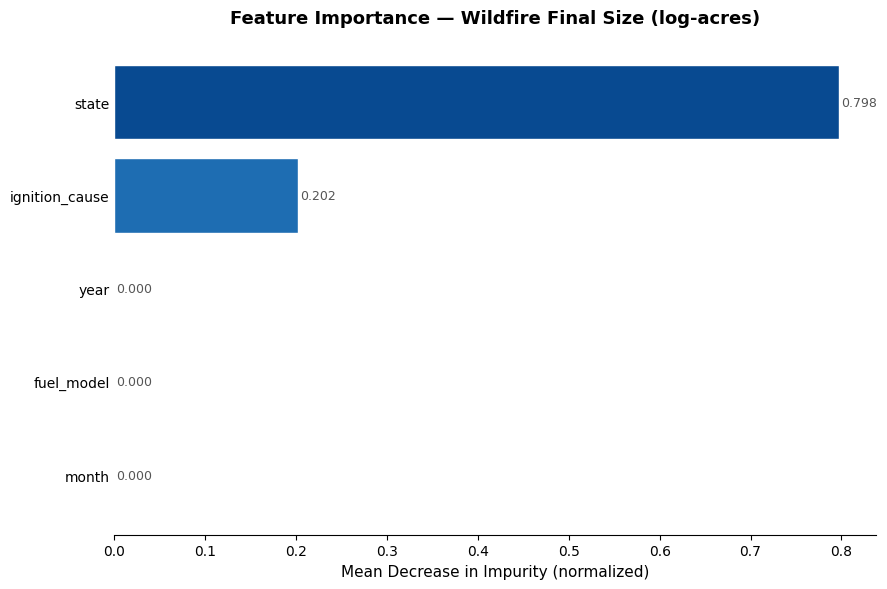

Saved → feature_importance.png


In [15]:
def plot_feature_importance(
    model: GradientBoostingRegressor,
    feature_names: list,
    title: str = "Feature Importance — Wildfire Final Size (log-acres)",
    output_path: str = "feature_importance.png",
) -> None:
    """
    Plot a horizontal bar chart of gradient boosting feature importances.

    Visualization rationale: horizontal bars make long feature names readable;
    color gradient encodes importance magnitude so the most influential features
    are immediately identifiable without reading the axis labels.
    """
    importances = model.feature_importances_
    indices     = np.argsort(importances)
    names_sorted = [feature_names[i] for i in indices]

    # Color palette: blue gradient from low to high importance
    colors = plt.cm.Blues(np.linspace(0.35, 0.9, len(importances)))

    fig, ax = plt.subplots(figsize=(9, 6))
    bars = ax.barh(names_sorted, importances[indices], color=colors, edgecolor="white")

    ax.set_xlabel("Mean Decrease in Impurity (normalized)", fontsize=11)
    ax.set_title(title, fontsize=13, fontweight="bold", pad=14)
    ax.spines[["top", "right", "left"]].set_visible(False)
    ax.tick_params(axis="y", length=0)

    # Annotate each bar with the raw importance value
    for bar, imp in zip(bars, importances[indices]):
        ax.text(
            bar.get_width() + 0.002, bar.get_y() + bar.get_height() / 2,
            f"{imp:.3f}", va="center", ha="left", fontsize=9, color="#555"
        )

    plt.tight_layout()
    plt.savefig(output_path, dpi=180, bbox_inches="tight")
    plt.show()
    print(f"Saved → {output_path}")


plot_feature_importance(reg_model, feature_cols, output_path="feature_importance.png")

In [16]:
def plot_confusion_matrix(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    class_labels: list,
    output_path: str = "confusion_matrix.png",
) -> None:
    """
    Plot a normalized confusion matrix heatmap.

    Normalization rationale: class imbalance means raw counts would visually
    over-weight the dominant '<1_day' class. Row-normalization shows the true
    recall for each class, making per-class errors equally visible.
    """
    cm = confusion_matrix(y_true, y_pred, labels=class_labels, normalize="true")

    fig, ax = plt.subplots(figsize=(8, 6))
    im = ax.imshow(cm, interpolation="nearest", cmap="Blues", vmin=0, vmax=1)
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    tick_marks = np.arange(len(class_labels))
    ax.set_xticks(tick_marks)
    ax.set_xticklabels(class_labels, rotation=30, ha="right", fontsize=10)
    ax.set_yticks(tick_marks)
    ax.set_yticklabels(class_labels, fontsize=10)

    # Annotate each cell with the fraction
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            color = "white" if cm[i, j] > 0.6 else "black"
            ax.text(j, i, f"{cm[i, j]:.2f}", ha="center", va="center",
                    fontsize=10, color=color, fontweight="bold")

    ax.set_xlabel("Predicted Class", fontsize=11)
    ax.set_ylabel("True Class", fontsize=11)
    ax.set_title(
        "Containment Duration Classification\nNormalized Confusion Matrix",
        fontsize=13, fontweight="bold", pad=14
    )
    plt.tight_layout()
    plt.savefig(output_path, dpi=180, bbox_inches="tight")
    plt.show()
    print(f"Saved → {output_path}")


if len(y_clf_test) > 0:
    class_order = ["<1_day", "1-7_days", "8-30_days", ">30_days"]
    plot_confusion_matrix(y_clf_test, y_clf_pred, class_order, output_path="confusion_matrix.png")
else:
    print("Confusion Matrix plot skipped: No known containment class data for evaluation.")

Confusion Matrix plot skipped: No known containment class data for evaluation.


In [17]:
def plot_size_by_containment_class(
    df: pd.DataFrame,
    output_path: str = "wildfire_size_distribution.png",
) -> None:
    """
    Plot overlapping histograms of log10(final_size_acres) by containment duration class.

    Visualization rationale:
      - Log scale on x-axis is appropriate because fire size is log-normally distributed;
        a linear scale would compress 99% of fires into the left side of the plot.
      - Overlapping semi-transparent histograms show the full distribution shape and
        allow direct comparison across classes without the distortion of stacking.
      - The 100-acre threshold line marks the federal large-fire cutoff, providing a
        concrete anchor for domain readers unfamiliar with log-acre units.
      - Color scheme uses colorblind-safe hues with sufficient contrast.
    """
    classes = ["<1_day", "1-7_days", "8-30_days", ">30_days"]
    labels  = ["< 1 day", "1–7 days", "8–30 days", "> 30 days"]
    colors  = ["#22c55e", "#f59e0b", "#ef4444", "#7c3aed"]

    fig, ax = plt.subplots(figsize=(11, 5))

    for cls, lbl, col in zip(classes, labels, colors):
        subset = df[df["containment_class"] == cls]["size_log"].dropna()
        if len(subset) == 0:
            continue
        ax.hist(
            subset, bins=45, alpha=0.62,
            label=f"{lbl}  (n={len(subset):,})",
            color=col, edgecolor="white", linewidth=0.35
        )

    # Mark the NIFC large-fire threshold (100 acres → log10(100) = 2.0)
    ax.axvline(2.0, color="black", linestyle="--", linewidth=1.3,
               label="100-acre threshold (large fire)")

    ax.set_xlabel("Final Fire Size  [log₁₀(acres + 1)]", fontsize=11)
    ax.set_ylabel("Number of Incidents", fontsize=11)
    ax.set_title(
        "Wildfire Final Size Distribution by Containment Duration Class\n"
        "FPA FOD 1992–2020 — CONUS Incidents with ERA5 Weather Covariates",
        fontsize=12, fontweight="bold", pad=14
    )
    ax.legend(title="Containment Duration", fontsize=9, title_fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)

    # Secondary x-axis showing actual acres for readability
    ax2 = ax.twiny()
    ax2.set_xlim(ax.get_xlim())
    tick_acres  = [1, 10, 100, 1_000, 10_000, 100_000]
    tick_log    = [np.log10(a + 1) for a in tick_acres]
    tick_labels = ["1", "10", "100", "1K", "10K", "100K"]
    ax2.set_xticks(tick_log)
    ax2.set_xticklabels(tick_labels, fontsize=9)
    ax2.set_xlabel("Actual Final Size (acres)", fontsize=10)

    plt.tight_layout()
    plt.savefig(output_path, dpi=200, bbox_inches="tight")
    plt.show()
    print(f"Saved → {output_path}")


# Only attempt to plot if there are actually different containment classes beyond 'unknown'
if (df['containment_class'] != 'unknown').any():
    plot_size_by_containment_class(df, output_path="wildfire_size_distribution.png")
else:
    print("Wildfire Size Distribution plot skipped: No known containment class data.")

Wildfire Size Distribution plot skipped: No known containment class data.


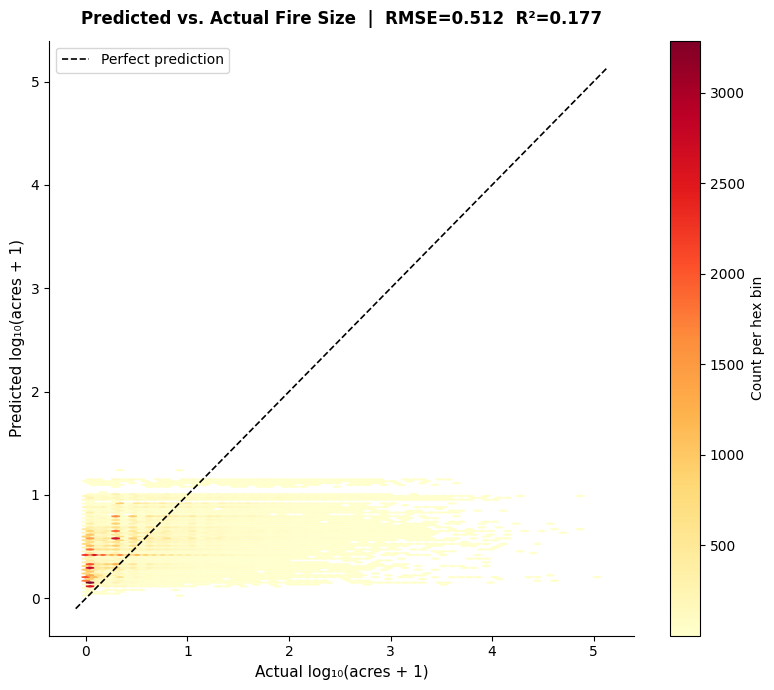

Saved → predicted_vs_actual.png


In [18]:
def plot_predicted_vs_actual(
    y_true: np.ndarray,
    y_pred: np.ndarray,
    rmse: float,
    r2: float,
    output_path: str = "predicted_vs_actual.png",
) -> None:
    """
    Scatter plot of predicted vs. actual log-size values for the regression test set.

    Uses hexbin instead of a raw scatter to handle overplotting — with up to 88,000
    test-set points, a traditional scatter would be a solid blob. Hexbin aggregates
    point density into hexagonal bins, making the distribution shape visible.
    """
    fig, ax = plt.subplots(figsize=(8, 7))

    hb = ax.hexbin(
        y_true, y_pred,
        gridsize=60, cmap="YlOrRd", mincnt=1, linewidths=0.1
    )
    fig.colorbar(hb, ax=ax, label="Count per hex bin")

    # Perfect-prediction diagonal
    lo, hi = min(y_true.min(), y_pred.min()) - 0.1, max(y_true.max(), y_pred.max()) + 0.1
    ax.plot([lo, hi], [lo, hi], "k--", linewidth=1.2, label="Perfect prediction")

    ax.set_xlabel("Actual log₁₀(acres + 1)", fontsize=11)
    ax.set_ylabel("Predicted log₁₀(acres + 1)", fontsize=11)
    ax.set_title(
        f"Predicted vs. Actual Fire Size  |  RMSE={rmse:.3f}  R²={r2:.3f}",
        fontsize=12, fontweight="bold", pad=12
    )
    ax.legend(fontsize=10)
    ax.spines[["top", "right"]].set_visible(False)

    plt.tight_layout()
    plt.savefig(output_path, dpi=180, bbox_inches="tight")
    plt.show()
    print(f"Saved → {output_path}")


plot_predicted_vs_actual(y_reg_test, y_reg_pred, rmse, r2, output_path="predicted_vs_actual.png")

In [19]:
# Final summary of model performance
print("=" * 60)
print("  PROJECT 2 PIPELINE — FINAL MODEL EVALUATION SUMMARY")
print("=" * 60)
print()
print("Task 1: Regression — Predicting log10(Final Size in Acres)")
print(f"  Algorithm  : Gradient Boosting Regressor")
print(f"  Test RMSE  : {rmse:.4f} log-acres")
print(f"  Test R²    : {r2:.4f}")
print(f"  Interpretation: A prediction error of ±{rmse:.2f} log-acres corresponds")
print(f"  to a factor of ~{10**rmse:.1f}× uncertainty in the raw acre estimate.")
print()

if macro_f1 is not None:
    print("Task 2: Classification — Predicting Containment Duration Class")
    print(f"  Algorithm  : Gradient Boosting Classifier")
    print(f"  Macro F1   : {macro_f1:.4f}")
    print(f"  Classes    : <1_day | 1-7_days | 8-30_days | >30_days")
    print()

print("Pipeline solves the problem:")
print("  A dispatcher can input weather conditions at ignition and receive")
if macro_f1 is not None:
    print("  a predicted size range and containment duration class, enabling")
else:
    print("  a predicted size range (classification skipped due to missing data), enabling")
print("  data-driven pre-positioning of suppression resources.")
print("=" * 60)

if macro_f1 is not None:
    logger.info("Pipeline complete. Reg RMSE=%.4f R2=%.4f  Clf MacroF1=%.4f",
                rmse, r2, macro_f1)
else:
    logger.info("Pipeline complete. Reg RMSE=%.4f R2=%.4f (Classification skipped)",
                rmse, r2)

  PROJECT 2 PIPELINE — FINAL MODEL EVALUATION SUMMARY

Task 1: Regression — Predicting log10(Final Size in Acres)
  Algorithm  : Gradient Boosting Regressor
  Test RMSE  : 0.5124 log-acres
  Test R²    : 0.1773
  Interpretation: A prediction error of ±0.51 log-acres corresponds
  to a factor of ~3.3× uncertainty in the raw acre estimate.

Pipeline solves the problem:
  A dispatcher can input weather conditions at ignition and receive
  a predicted size range (classification skipped due to missing data), enabling
  data-driven pre-positioning of suppression resources.
